In [1]:
# load master dataset
import pandas as pd
import numpy as np

df = pd.read_csv('data/processed/master_dataset_merged.csv')

# Quick check: How many rows and columns?
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")

Dataset shape: (276, 20)

Column names: ['race_number', 'race_name', 'race_date', 'primary_sponsor', 'finish_position', 'laps_led', 'merge_key', 'reddit_mention_count', 'youtube_total_view_count', 'youtube_total_like_count', 'youtube_total_comment_count', 'youtube_total_duration_seconds', 'num_youtube_videos', 'news_total_mentions', 'news_weighted_mentions', 'news_passing_mentions', 'news_primary_mentions', 'news_secondary_mentions', 'driver_search_interest', 'sponsor_search_interest']


## Distribution check: predictor histograms

Before fitting anything, look at the shape of each candidate predictor. A histogram
answers three questions at a glance: is it skewed (candidate for a log transform),
is it zero-inflated (candidate for a two-part model), and does it have extreme
outliers (candidate for winsorizing). We build one reusable plotting function so
every panel is visually consistent, then run it across all numeric predictors.

In [2]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

# --- design tokens (single sequential hue + recessive chrome) ---
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
FILL = "#86b6ef"      # sequential step 250 (fill)
FILL_EDGE = "#2a78d6" # sequential step 450 (edge / mean line)
SURFACE = "#fcfcfb"

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Segoe UI", "Helvetica Neue", "Arial", "sans-serif"]


def plot_histogram(data, column, ax=None, bins=30, log=False):
    """One consistently-styled histogram panel for a single numeric predictor."""
    series = data[column].dropna()
    values = np.log1p(series) if log else series

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3.2), dpi=150)

    ax.set_facecolor(SURFACE)
    ax.hist(values, bins=bins, color=FILL, edgecolor=SURFACE, linewidth=0.5, zorder=2)

    mean_val, median_val = values.mean(), values.median()
    ax.axvline(mean_val, color=FILL_EDGE, linewidth=1.5, zorder=3)
    ax.axvline(median_val, color=INK_SECONDARY, linewidth=1, linestyle="--", zorder=3)

    ymax = ax.get_ylim()[1]
    ax.text(mean_val, ymax * 1.02, "mean", color=FILL_EDGE, fontsize=8,
            ha="center", va="bottom")
    ax.text(median_val, ymax * 1.14, "median", color=INK_SECONDARY, fontsize=8,
            ha="center", va="bottom")

    # skew + normality read, annotated directly rather than left to the eye
    skew = stats.skew(series)
    if 3 <= len(series) <= 5000:
        _, p = stats.shapiro(series)
        stat_label = f"skew={skew:.2f}  |  Shapiro–Wilk p={p:.3f}"
    else:
        stat_label = f"skew={skew:.2f}"
    ax.text(0.02, 0.96, stat_label, transform=ax.transAxes, fontsize=7.5,
            color=INK_MUTED, ha="left", va="top")

    title = column.replace("_", " ")
    if log:
        title += "  (log1p)"
    ax.set_title(title, fontsize=10, color=INK_PRIMARY, loc="left", pad=8)

    ax.grid(axis="y", color=GRIDLINE, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.tick_params(axis="both", colors=INK_MUTED, labelsize=8, length=0)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=4))

    return ax

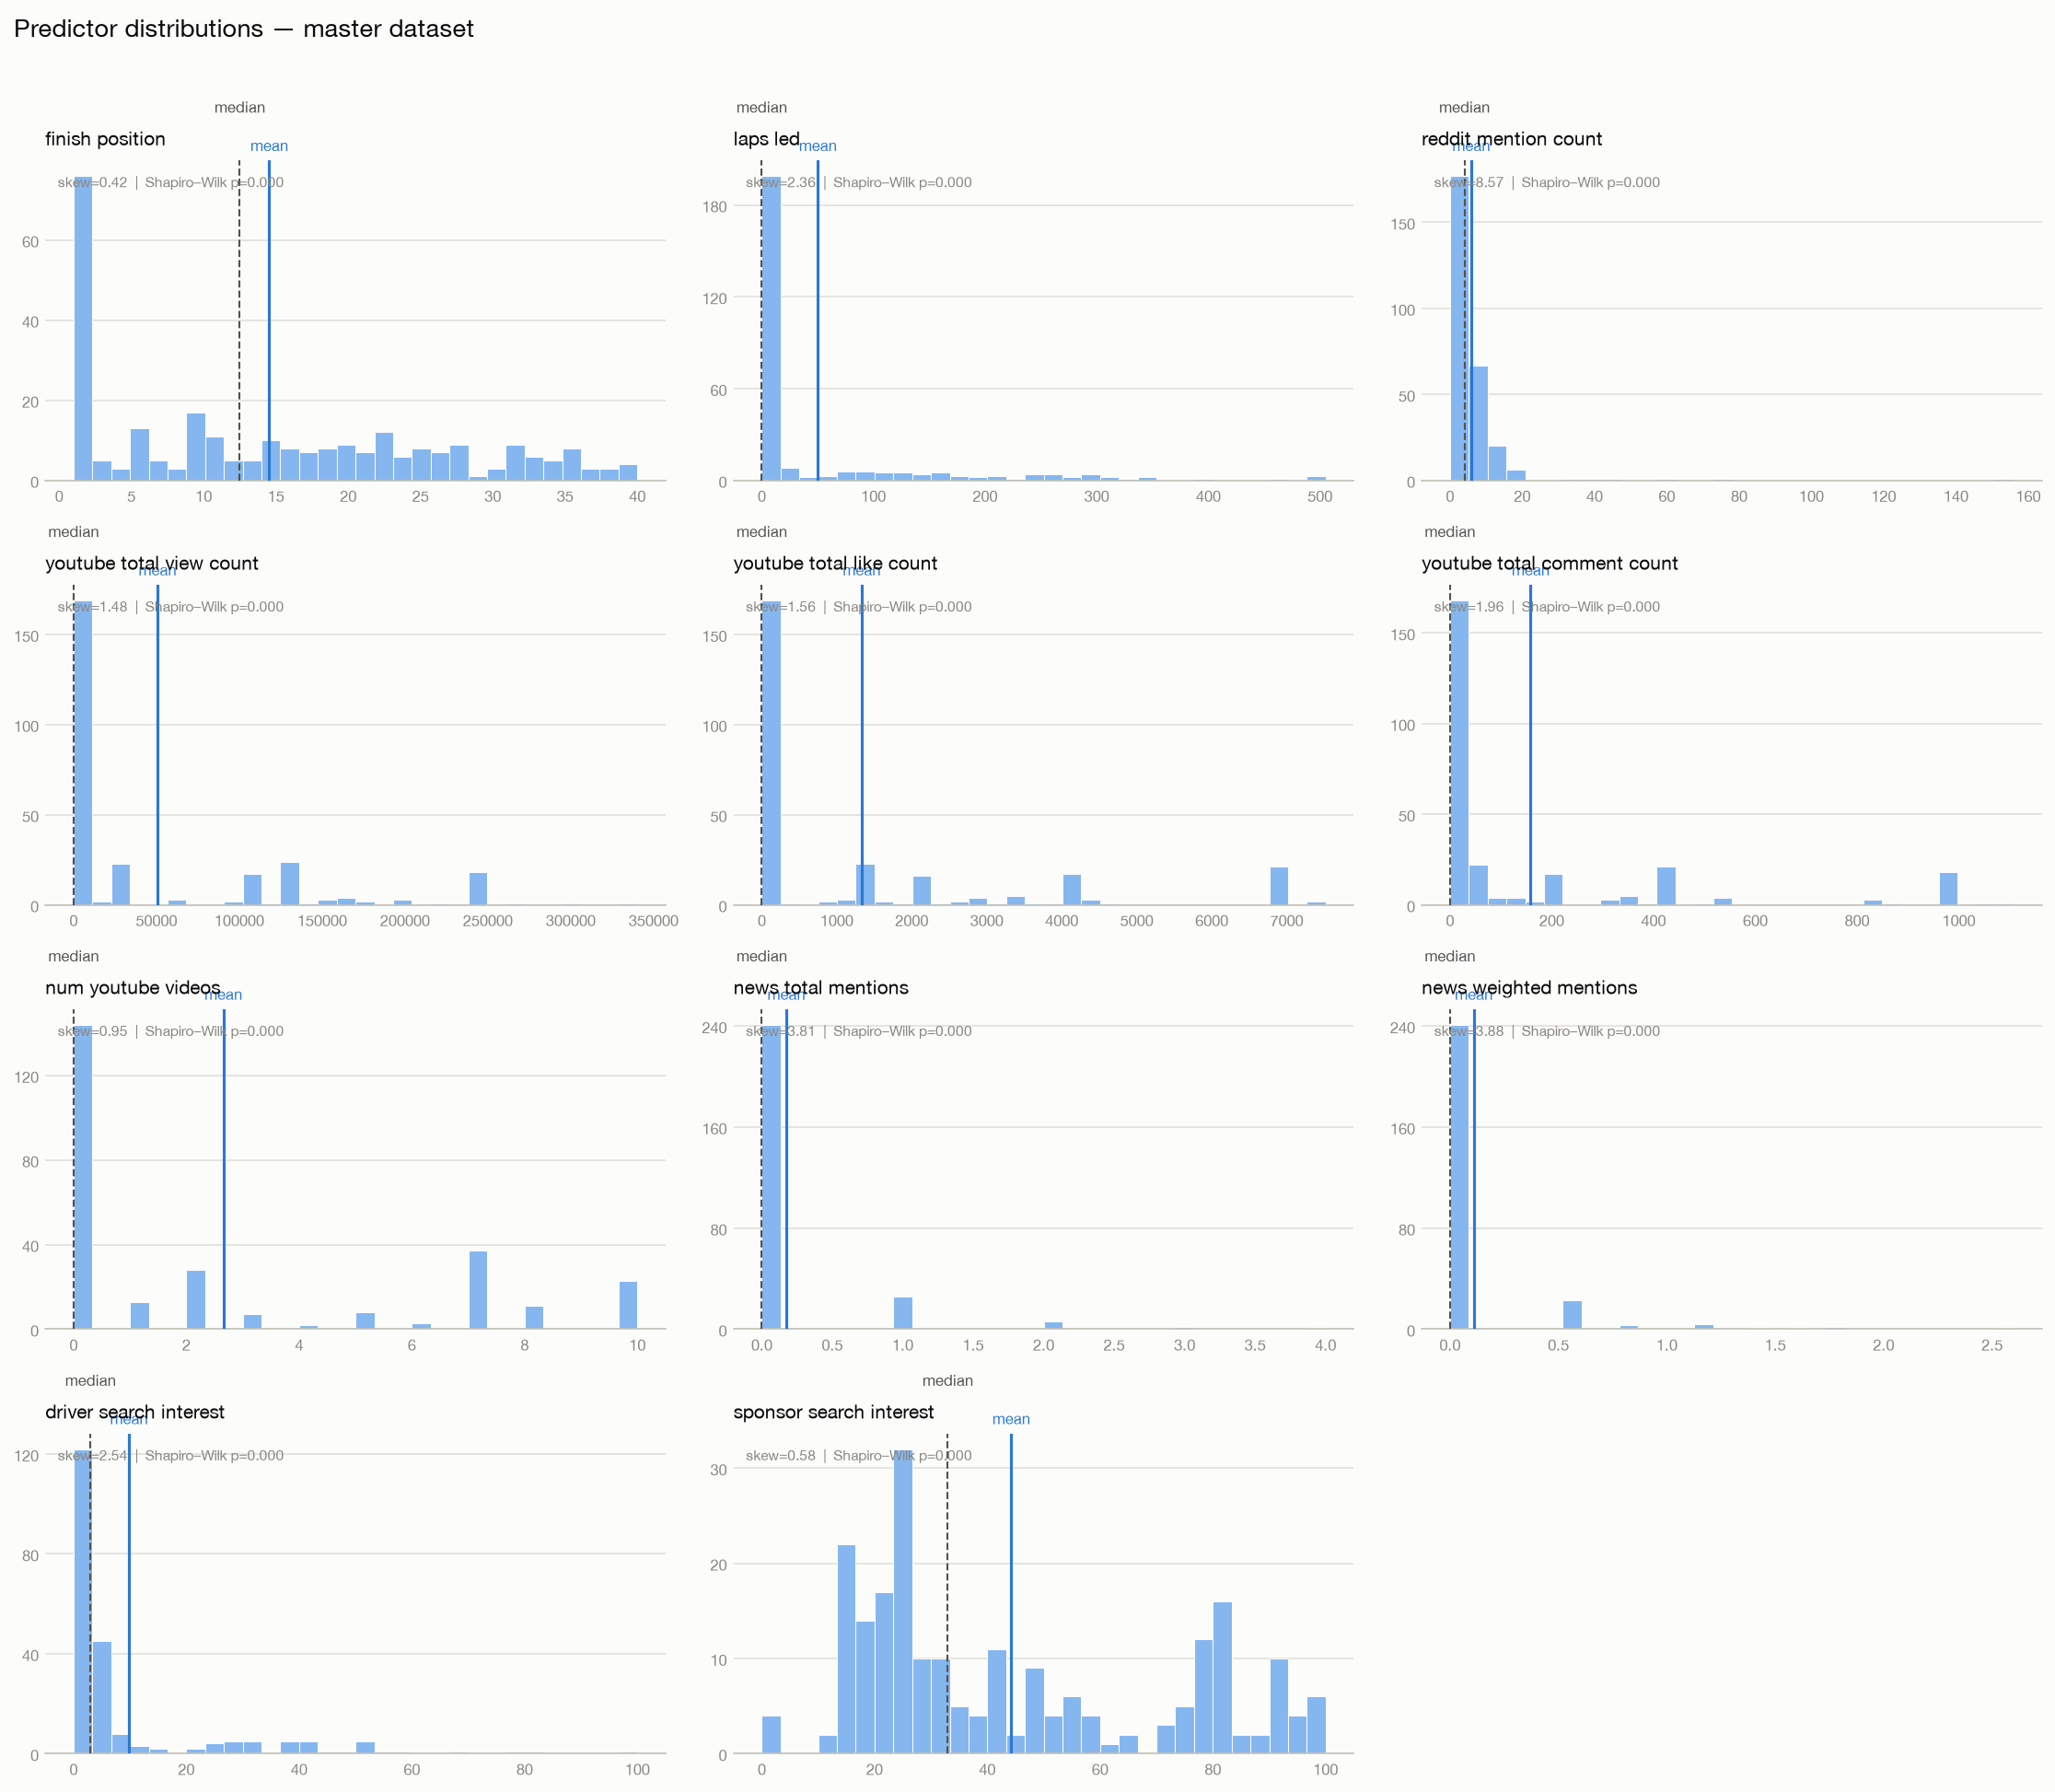

In [3]:
predictor_cols = [
    "finish_position", "laps_led", "reddit_mention_count",
    "youtube_total_view_count", "youtube_total_like_count",
    "youtube_total_comment_count", "num_youtube_videos",
    "news_total_mentions", "news_weighted_mentions",
    "driver_search_interest", "sponsor_search_interest",
]

n_cols = 3
n_rows = int(np.ceil(len(predictor_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.2 * n_rows), dpi=150)
fig.patch.set_facecolor(SURFACE)
axes = axes.flatten()

for ax, col in zip(axes, predictor_cols):
    plot_histogram(df, col, ax=ax)

for ax in axes[len(predictor_cols):]:
    ax.axis("off")

fig.suptitle("Predictor distributions — master dataset", fontsize=13,
             color=INK_PRIMARY, x=0.01, ha="left", y=1.01)
fig.tight_layout()
plt.show()